In [ ]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 628.9 kB/s eta 0:01:54
    --------------------------------------- 1.0/72.0 MB 1.1 MB/s eta 0:01:08
    --------------------------------------- 1.6/72.0 MB 1.3 MB/s eta 0:00:53
   - -------------------------------------- 2.1/72.0 MB 1.6 MB/s eta 0:00:45
   - -------------------------------------- 2.4/72.0 MB 1.6 MB/s eta 0:00:45
   - -------------------------------------- 2.6/72.0 MB 1.5 MB/s eta 0:00:46
   - -------------------------------------- 2.9/72.0 MB 1.5 MB/s eta 0:00:47
   - -------------------------------------- 3.4/72.0 MB 1.6 MB/s eta 0:00:44
   -- ------------------------------------- 4.2/72.0 MB 1.8 MB/s eta 0:00:39
   -- -------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install scipy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import h5py
import os
import glob
from datetime import datetime, timedelta
from scipy import signal
from tqdm import tqdm

# --- CONFIGURATION ---
LABEL_FILE = r"E:\seismic\output\labels\labels.csv"
RAW_DATA_ROOT = r"E:\seismic\raw_data"
OUTPUT_FILE = "multimodal_dataset.npz"

# SETTINGS (CONFIRMED)
FS = 20.0
WINDOW_SECONDS = 30
WINDOW_SIZE = int(WINDOW_SECONDS * FS) # 600 samples
HALF_WINDOW = WINDOW_SIZE // 2

def robust_normalize(data):
    # Standard Score Normalization
    mean = np.mean(data)
    std = np.std(data)
    if std == 0: return np.zeros_like(data)
    return (data - mean) / std

def compute_spectrogram(waveform, fs):
    # waveform shape: (Time,) or (Time, Channels). We use the first channel.
    if waveform.ndim > 1:
        trace = waveform[:, 0]
    else:
        trace = waveform

    # Compute Spectrogram
    f, t, Sxx = signal.spectrogram(trace, fs, nperseg=64, noverlap=32)
    # Log scale for better ML learning
    Sxx = np.log1p(Sxx)
    # Normalize 0-1
    return (Sxx - Sxx.min()) / (Sxx.max() - Sxx.min() + 1e-6)

def compute_csdm(waveform, fs):
    # waveform shape: (Time, Channels)
    # If single channel, this is just PSD. If 3 channels, it's 3x3 matrix.

    # 1. FFT
    fft_data = np.fft.fft(waveform, axis=0)

    # 2. Outer Product (Channel_i * Channel_j*)
    # Result shape: (Freq, Channels, Channels)
    # We average over frequencies to get a single spatial matrix (Simple CSDM)
    # Or keep frequency dim. For simplicity/speed, we treat it as a correlation matrix.

    if waveform.ndim == 1:
        # Fake CSDM for 1 channel (1x1)
        return np.array([[np.var(waveform)]])

    n_channels = waveform.shape[1]
    csdm = np.zeros((n_channels, n_channels), dtype=complex)

    # Compute covariance matrix (approx CSDM averaged)
    # (Channels x Time) @ (Time x Channels)
    csdm = np.dot(waveform.T, waveform) / len(waveform)

    # We only need magnitude for ML usually
    return np.abs(csdm)

def generate_multimodal():
    print(f"📂 Scanning files in {RAW_DATA_ROOT}...")
    all_files = glob.glob(os.path.join(RAW_DATA_ROOT, "**", "*.h5"), recursive=True)

    # Index files
    file_map = {}
    for f_path in all_files:
        try:
            parts = os.path.basename(f_path).split('_')
            # Adjust index based on your filename format (Brienz_20Hz_...)
            if len(parts) >= 5:
                # Looking for date/time parts.
                # Brienz_20Hz_4m_20230516_124613.500.h5
                # Date=Part[3], Time=Part[4]
                dt_str = f"{parts[3]} {parts[4].replace('.h5', '')}"
                dt = datetime.strptime(dt_str, "%Y%m%d %H%M%S.%f")
                file_map[dt] = f_path
        except: continue
    sorted_starts = sorted(file_map.keys())

    print(f"📄 Processing labels from {LABEL_FILE}...")
    df = pd.read_csv(LABEL_FILE)
    df['dt'] = pd.to_datetime(df['time'])

    X_wave = [] # Time Series
    X_spec = [] # Spectrogram
    X_csdm = [] # Spatial Matrix
    y_list = []

    success_count = 0

    for _, row in tqdm(df.iterrows(), total=len(df)):
        target = row['dt']

        # Find File
        f_path = None
        f_start = None
        for start_t in reversed(sorted_starts):
            if start_t <= target < (start_t + timedelta(seconds=300)):
                f_path = file_map[start_t]
                f_start = start_t
                break

        if not f_path: continue

        try:
            with h5py.File(f_path, 'r') as f:
                idx = int((target - f_start).total_seconds() * FS)
                s_idx, e_idx = idx - HALF_WINDOW, idx + HALF_WINDOW

                if s_idx < 0 or e_idx > f['Traces'].shape[0]: continue

                # 1. Get Raw Data
                raw = f['Traces'][s_idx:e_idx, :] # (600, Channels)

                # Handle Single Channel case by reshaping
                if raw.ndim == 1:
                    raw = raw.reshape(-1, 1)

                # Normalize
                norm_wave = robust_normalize(raw)

                # 2. Compute Features
                spec = compute_spectrogram(norm_wave, FS)
                csdm = compute_csdm(norm_wave, FS)

                # Append
                X_wave.append(norm_wave)
                X_spec.append(spec)
                X_csdm.append(csdm)
                y_list.append(row['label'])
                success_count += 1

        except Exception as e: continue

    if success_count == 0:
        print("❌ Error: No data processed. Check paths/timestamps.")
        return

    print(f"✅ Saving {success_count} samples to {OUTPUT_FILE}...")
    np.savez(OUTPUT_FILE,
             X_wave=np.array(X_wave),
             X_spec=np.array(X_spec),
             X_csdm=np.array(X_csdm),
             y=np.array(y_list))
    print("🎉 DONE. You are ready for the fusion model.")

if __name__ == "__main__":
    generate_multimodal()

📂 Scanning files in E:\seismic\raw_data...
📄 Processing labels from E:\seismic\output\labels\labels.csv...


100%|██████████████████████████████████████████████████████████████████████████████| 1491/1491 [04:35<00:00,  5.42it/s]


✅ Saving 1341 samples to multimodal_dataset.npz...
🎉 DONE. You are ready for the fusion model.


⚙️ Computation Device: cpu
📊 [Phase 1] Visualizing Data Samples...


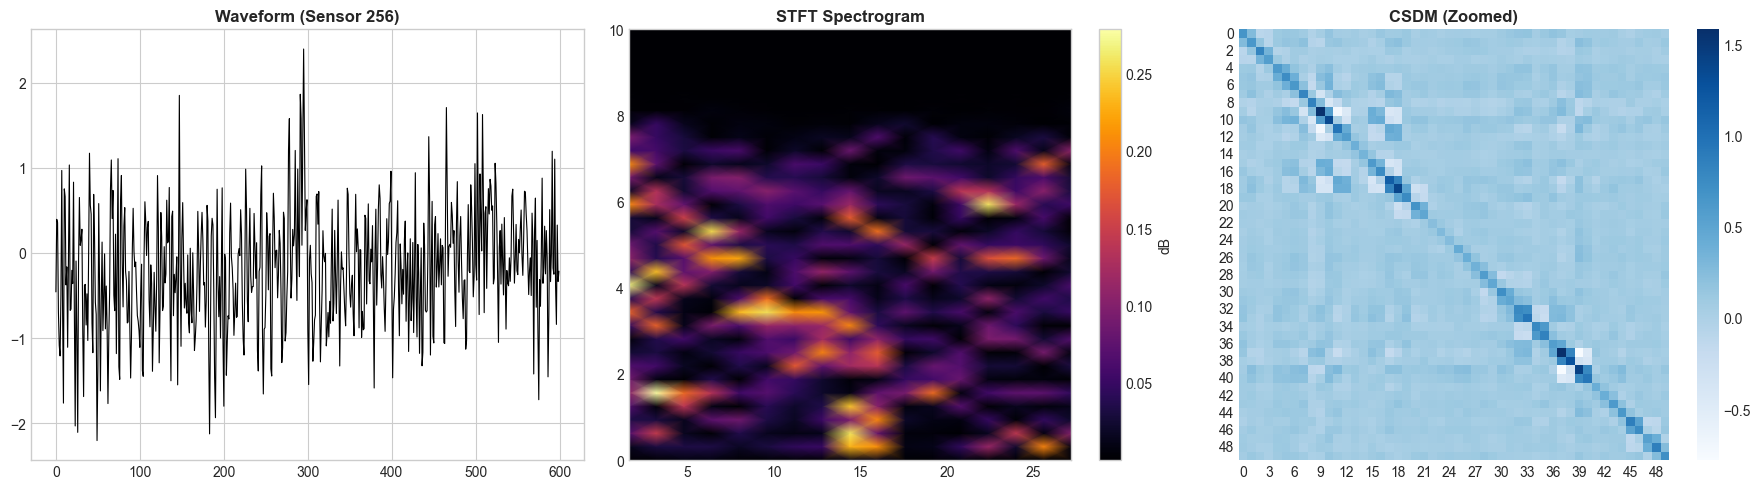


📦 [Phase 2] Loading Data...
✅ Data Ready. Train: 938 | Val: 201 | Test: 202

🌲 MODEL A: XGBoost


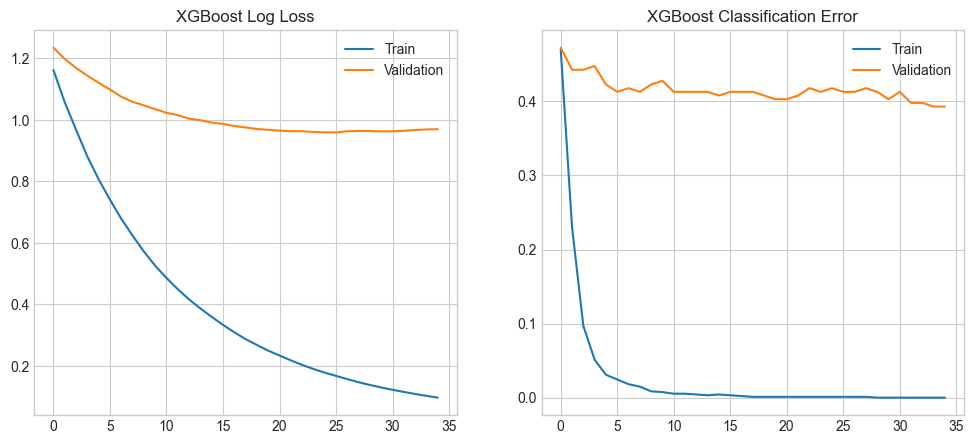

               precision    recall  f1-score   support

     Rockfall       0.69      0.92      0.78       107
    Landslide       0.00      0.00      0.00        17
Anthropogenic       0.63      0.63      0.63        52
      Ambient       0.80      0.15      0.26        26

     accuracy                           0.67       202
    macro avg       0.53      0.43      0.42       202
 weighted avg       0.63      0.67      0.61       202



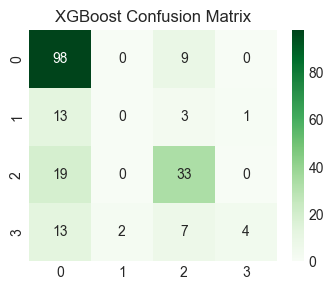


⏳ MODEL B: LSTM

🚀 Training LSTM...
    Ep 5: Train Loss 1.097 | Val Loss 1.071 | Val Acc 58.7%
    Ep 10: Train Loss 1.067 | Val Loss 1.120 | Val Acc 52.7%
    Ep 15: Train Loss 1.074 | Val Loss 1.094 | Val Acc 56.2%


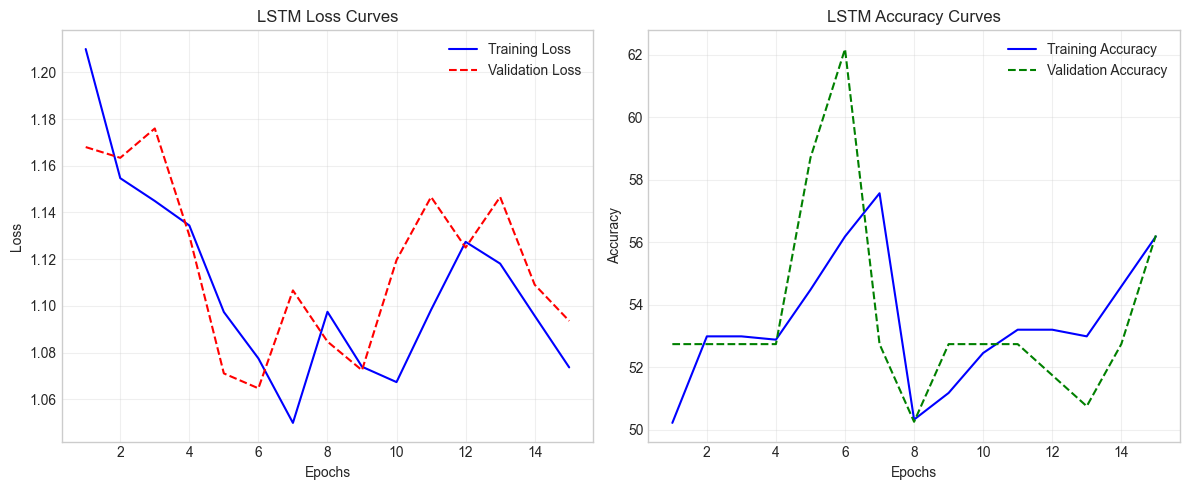

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

               precision    recall  f1-score   support

     Rockfall       0.62      0.93      0.74       107
    Landslide       0.00      0.00      0.00        17
Anthropogenic       0.49      0.35      0.40        52
      Ambient       0.00      0.00      0.00        26

     accuracy                           0.58       202
    macro avg       0.28      0.32      0.29       202
 weighted avg       0.45      0.58      0.50       202



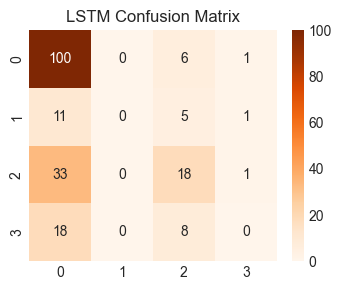


🖼️ MODEL C: CNN

🚀 Training CNN...
    Ep 5: Train Loss 0.869 | Val Loss 0.941 | Val Acc 62.7%
    Ep 10: Train Loss 0.781 | Val Loss 0.936 | Val Acc 64.2%
    Ep 15: Train Loss 0.690 | Val Loss 0.895 | Val Acc 63.7%


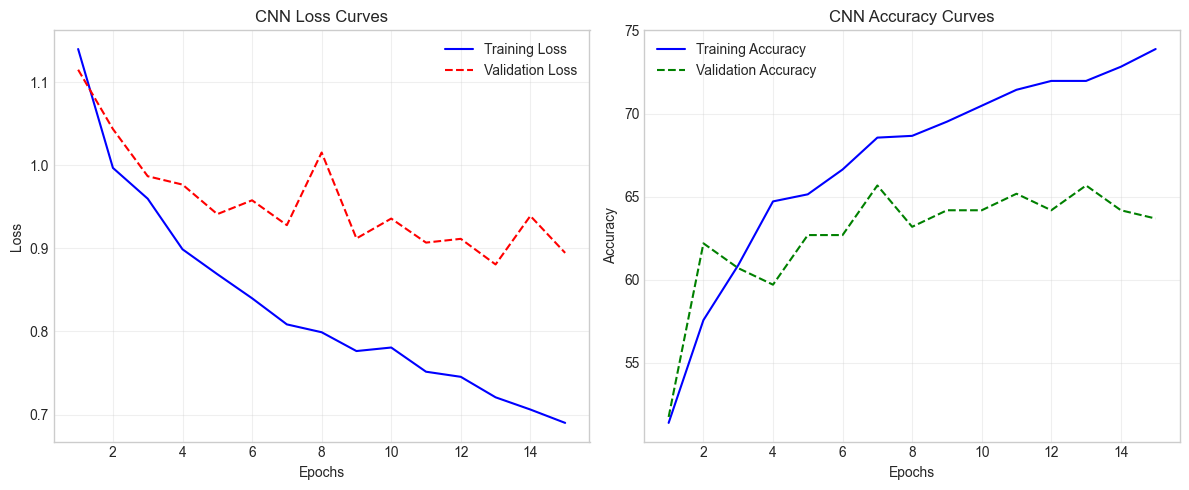

               precision    recall  f1-score   support

     Rockfall       0.69      0.88      0.77       107
    Landslide       0.00      0.00      0.00        17
Anthropogenic       0.68      0.58      0.62        52
      Ambient       0.81      0.50      0.62        26

     accuracy                           0.68       202
    macro avg       0.55      0.49      0.50       202
 weighted avg       0.65      0.68      0.65       202



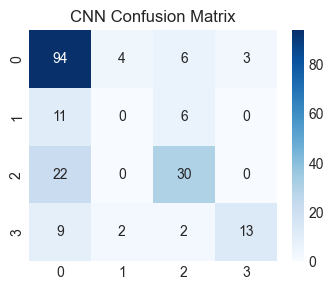


✅ Execution Complete.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy import signal
import os
import gc

# --- CONFIGURATION ---
DATASET_FILE = "multimodal_dataset.npz"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_NAMES = ['Rockfall', 'Landslide', 'Anthropogenic', 'Ambient']
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 0.001
MAX_SAMPLES = None

plt.style.use('seaborn-v0_8-whitegrid')
print(f"⚙️ Computation Device: {DEVICE}")
print("="*60)

# ==========================================
# 1. VISUALIZATION
# ==========================================
print("📊 [Phase 1] Visualizing Data Samples...")

if not os.path.exists(DATASET_FILE):
    raise FileNotFoundError(f"❌ {DATASET_FILE} not found.")

try:
    data = np.load(DATASET_FILE, mmap_mode='r')
    y_all = data['y']
    landslide_idxs = np.where(y_all == 1)[0]
    idx = landslide_idxs[0] if len(landslide_idxs) > 0 else 0

    raw_wave_sample = data['X_wave'][idx]
    mid_chan = raw_wave_sample.shape[1] // 2 if raw_wave_sample.ndim > 1 else 0
    clean_wave = raw_wave_sample[:, mid_chan] if raw_wave_sample.ndim > 1 else raw_wave_sample

    # Spectrogram (STFT + Inferno)
    f, t, Sxx = signal.spectrogram(clean_wave, fs=20.0, nperseg=64, noverlap=32)

    if raw_wave_sample.ndim > 1:
        wave_small = raw_wave_sample[:, :50]
        csdm_zoom = np.dot(wave_small.T, wave_small) / len(wave_small)
    else:
        csdm_zoom = np.array([[1]])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(clean_wave, color='black', linewidth=0.8)
    axes[0].set_title(f"Waveform (Sensor {mid_chan})", fontweight='bold')

    im_spec = axes[1].pcolormesh(t, f, np.log1p(Sxx), shading='gouraud', cmap='inferno')
    axes[1].set_title("STFT Spectrogram", fontweight='bold')
    plt.colorbar(im_spec, ax=axes[1], label='dB')

    sns.heatmap(csdm_zoom, cmap="Blues", ax=axes[2], square=True, cbar=True)
    axes[2].set_title("CSDM (Zoomed)", fontweight='bold')

    plt.tight_layout()
    plt.show() #

except Exception as e:
    print(f"\n⚠️ Visualization skipped: {e}")

# ==========================================
# 2. DATA LOADING
# ==========================================
print("\n📦 [Phase 2] Loading Data...")

if 'data' in locals(): del data
gc.collect()
data = np.load(DATASET_FILE, mmap_mode='r')
total_samples = len(data['y'])
limit = min(MAX_SAMPLES, total_samples) if MAX_SAMPLES else total_samples

y = data['y'][:limit].astype(int)

try:
    X_wave = data['X_wave'][:limit, :, :3].astype(np.float32)
except MemoryError:
    limit = 500
    y = data['y'][:limit].astype(int)
    X_wave = data['X_wave'][:limit, :, :3].astype(np.float32)
    print(f"    ⚠️ Resized to {limit} samples.")

X_spec = data['X_spec'][:limit].astype(np.float32)

try:
    X_csdm = data['X_csdm'][:limit, :3, :3].astype(np.float32)
except:
    X_csdm = np.zeros((limit, 3, 3), dtype=np.float32)

del data
gc.collect()

indices = np.arange(len(y))
idx_train, idx_temp, y_train, y_temp = train_test_split(indices, y, test_size=0.30, stratify=y, random_state=42)
idx_val, idx_test, y_val, y_test = train_test_split(idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"✅ Data Ready. Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# ==========================================
# 3. UTILITIES
# ==========================================
class SeismicDataset(Dataset):
    def __init__(self, x_data, y_data, augment=False):
        self.x = x_data
        self.y = y_data
        self.augment = augment
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        sample = self.x[idx]
        if self.augment:
            noise = np.random.normal(0, 0.05, sample.shape).astype(np.float32)
            sample = sample + noise
        return torch.from_numpy(sample).float(), torch.tensor(self.y[idx]).long()

# --- DUAL LINE PLOTTING FUNCTION ---
def plot_history(hist, title, metric_name="Accuracy"):
    epochs = range(1, len(hist['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plot (Train vs Val)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, hist['val_loss'], 'r--', label='Validation Loss')
    plt.title(f"{title} Loss Curves")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Metric Plot (Train vs Val)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['train_acc'], 'b-', label=f'Training {metric_name}')
    plt.plot(epochs, hist['val_acc'], 'g--', label=f'Validation {metric_name}')
    plt.title(f"{title} {metric_name} Curves")
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def train_torch_model(model, train_loader, val_loader, name):
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n🚀 Training {name}...")
    for ep in range(EPOCHS):
        model.train()
        t_losses = []; t_correct = 0; t_total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            t_losses.append(loss.item())
            _, pred = torch.max(out, 1)
            t_correct += (pred == yb).sum().item()
            t_total += yb.size(0)

        model.eval()
        v_losses = []; v_correct = 0; v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = crit(out, yb)
                v_losses.append(loss.item())
                _, pred = torch.max(out, 1)
                v_correct += (pred == yb).sum().item()
                v_total += yb.size(0)

        avg_t_loss = np.mean(t_losses)
        avg_v_loss = np.mean(v_losses)
        acc_t = 100 * t_correct / t_total
        acc_v = 100 * v_correct / v_total

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['train_acc'].append(acc_t)
        history['val_acc'].append(acc_v)

        if (ep+1)%5==0:
            print(f"    Ep {ep+1}: Train Loss {avg_t_loss:.3f} | Val Loss {avg_v_loss:.3f} | Val Acc {acc_v:.1f}%")

    return history

# ==========================================
# 4. MODEL A: XGBOOST (Now with Graphs!)
# ==========================================
print("\n" + "="*60)
print("🌲 MODEL A: XGBoost")

def get_flat(idxs):
    w = X_wave[idxs].reshape(len(idxs), -1)
    c = X_csdm[idxs].reshape(len(idxs), -1)
    return np.hstack([w, c])

X_xgb_train = get_flat(idx_train)
X_xgb_val = get_flat(idx_val)
X_xgb_test = get_flat(idx_test)

clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    eval_metric=["merror", "mlogloss"], # Log metrics
    early_stopping_rounds=10
)

# Pass eval_set to capture history
clf.fit(X_xgb_train, y_train, eval_set=[(X_xgb_train, y_train), (X_xgb_val, y_val)], verbose=False)

# Extract History for Plotting
results = clf.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# Plot XGBoost History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
plt.legend(); plt.title('XGBoost Log Loss')
plt.subplot(1, 2, 2)
plt.plot(x_axis, results['validation_0']['merror'], label='Train')
plt.plot(x_axis, results['validation_1']['merror'], label='Validation')
plt.legend(); plt.title('XGBoost Classification Error')
plt.show() #

preds = clf.predict(X_xgb_test)
print(classification_report(y_test, preds, target_names=TARGET_NAMES))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix"); plt.show()

# ==========================================
# 5. MODEL B: LSTM
# ==========================================
print("\n" + "="*60)
print("⏳ MODEL B: LSTM")

train_ds = SeismicDataset(X_wave[idx_train], y_train, augment=True)
val_ds = SeismicDataset(X_wave[idx_val], y_val)
test_ds = SeismicDataset(X_wave[idx_test], y_test)

tl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
vl = DataLoader(val_ds, batch_size=BATCH_SIZE)
testl = DataLoader(test_ds, batch_size=1)

class LSTMNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lstm = nn.LSTM(dim, 64, 2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 4)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = LSTMNet(X_wave.shape[2]).to(DEVICE)
hist = train_torch_model(model_lstm, tl, vl, "LSTM")
plot_history(hist, "LSTM") #

preds = []
model_lstm.eval()
with torch.no_grad():
    for xb, yb in testl: preds.append(torch.argmax(model_lstm(xb.to(DEVICE)), 1).item())

print(classification_report(y_test, preds, target_names=TARGET_NAMES))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Oranges')
plt.title("LSTM Confusion Matrix"); plt.show()

# ==========================================
# 6. MODEL C: CNN
# ==========================================
print("\n" + "="*60)
print("🖼️ MODEL C: CNN")

X_spec_cnn = X_spec[:, np.newaxis, :, :]

train_ds = SeismicDataset(X_spec_cnn[idx_train], y_train)
val_ds = SeismicDataset(X_spec_cnn[idx_val], y_val)
test_ds = SeismicDataset(X_spec_cnn[idx_test], y_test)

tl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
vl = DataLoader(val_ds, batch_size=BATCH_SIZE)
testl = DataLoader(test_ds, batch_size=1)

class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(), nn.Linear(1024, 4)
        )
    def forward(self, x): return self.net(x)

model_cnn = CNNNet().to(DEVICE)
hist = train_torch_model(model_cnn, tl, vl, "CNN")
plot_history(hist, "CNN") #

preds = []
model_cnn.eval()
with torch.no_grad():
    for xb, yb in testl: preds.append(torch.argmax(model_cnn(xb.to(DEVICE)), 1).item())

print(classification_report(y_test, preds, target_names=TARGET_NAMES))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title("CNN Confusion Matrix"); plt.show()

print("\n✅ Execution Complete.")

⚙️ Computation Device: cpu
📊 [Phase 1] Visualizing Data Samples...


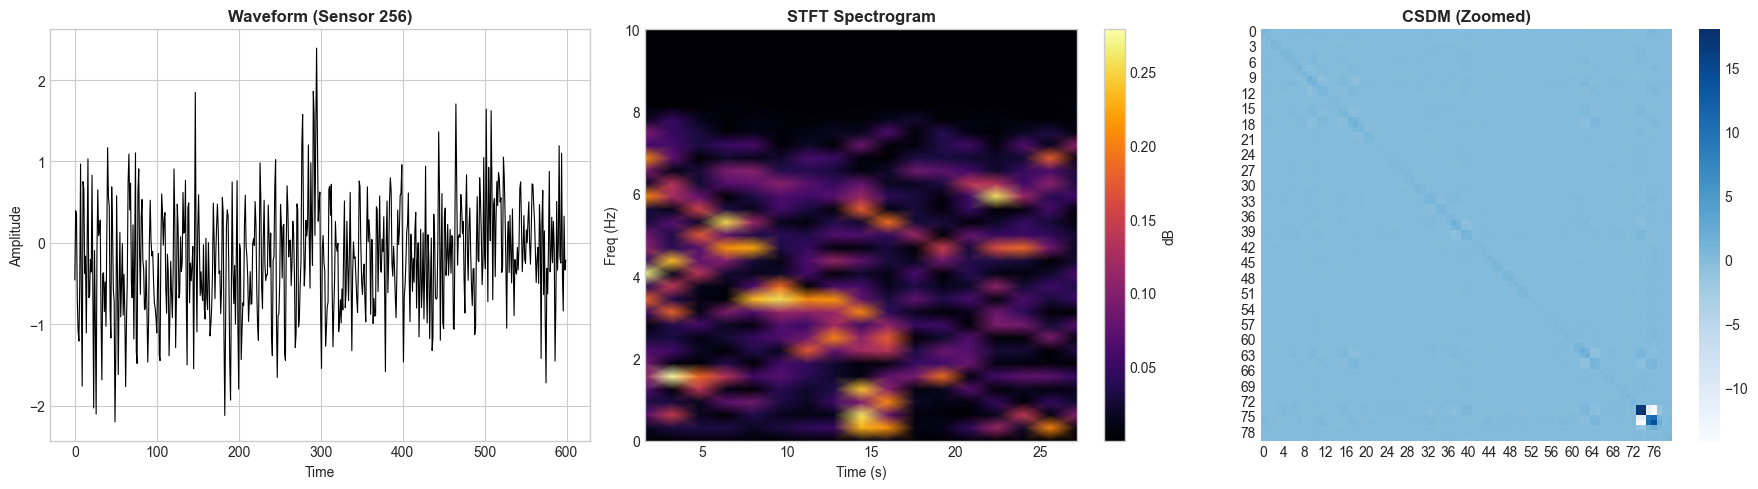


📦 [Phase 2] Loading Data...
    Train: 938 | Test: 403

🔹 SCENARIO A: PENALTY (Weighted)

🔹 SCENARIO B: SMOTE (Synthetic)
    Regenerating Spectrograms...

Method               | Metric     | XGBoost  | LSTM     | CNN     
-----------------------------------------------------------------
--- Penalty ---
Penalty              | accuracy   | 0.61     | 0.53     | 0.63
Penalty              | recall     | 0.03     | 0.03     | 0.14
Penalty              | f1         | 0.38     | 0.37     | 0.51
--- SMOTE ---
SMOTE                | accuracy   | 0.57     | 0.36     | 0.60
SMOTE                | recall     | 0.11     | 0.06     | 0.37
SMOTE                | f1         | 0.36     | 0.28     | 0.52


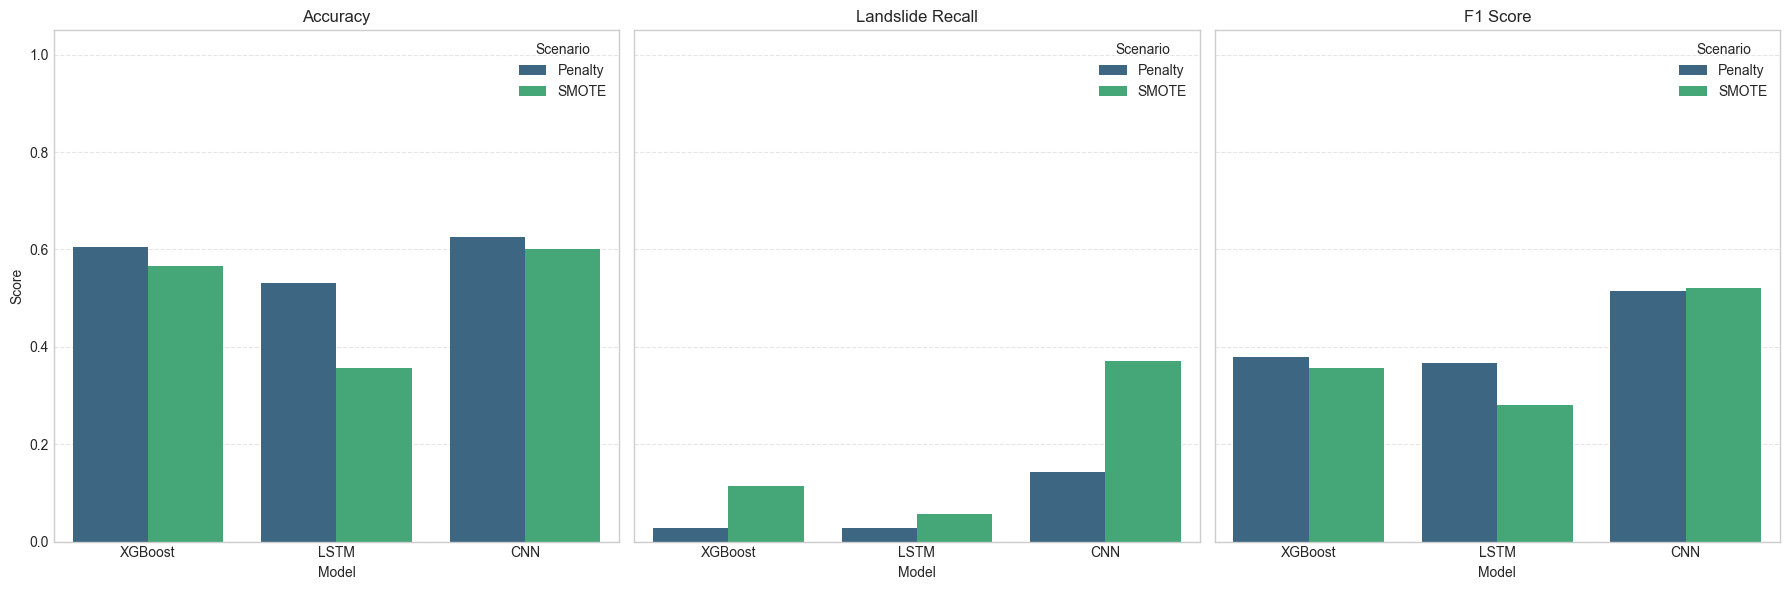


✅ Comparison Complete.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import signal
import os
import gc

DATASET_FILE = "multimodal_dataset.npz"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_NAMES = ['Rockfall', 'Landslide', 'Anthropogenic', 'Ambient']
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 0.001
MAX_SAMPLES = None

plt.style.use('seaborn-v0_8-whitegrid')
print(f"⚙️ Computation Device: {DEVICE}")
print("="*60)

print("📊 [Phase 1] Visualizing Data Samples...")

if not os.path.exists(DATASET_FILE):
    raise FileNotFoundError(f"❌ {DATASET_FILE} not found.")

try:
    data = np.load(DATASET_FILE, mmap_mode='r')
    y_all = data['y']
    landslide_idxs = np.where(y_all == 1)[0]
    idx = landslide_idxs[0] if len(landslide_idxs) > 0 else 0

    raw_wave_sample = data['X_wave'][idx]
    mid_chan = raw_wave_sample.shape[1] // 2 if raw_wave_sample.ndim > 1 else 0
    clean_wave = raw_wave_sample[:, mid_chan] if raw_wave_sample.ndim > 1 else raw_wave_sample

    f, t, Sxx = signal.spectrogram(clean_wave, fs=20.0, nperseg=64, noverlap=32)

    if raw_wave_sample.ndim > 1:
        wave_small = raw_wave_sample[:, :80]
        csdm_zoom = np.dot(wave_small.T, wave_small) / len(wave_small)
    else:
        csdm_zoom = np.array([[1]])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(clean_wave, color='black', linewidth=0.8)
    axes[0].set_title(f"Waveform (Sensor {mid_chan})", fontweight='bold')
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Amplitude")

    im_spec = axes[1].pcolormesh(t, f, np.log1p(Sxx), shading='gouraud', cmap='inferno')
    axes[1].set_title("STFT Spectrogram", fontweight='bold')
    axes[1].set_ylabel("Freq (Hz)")
    axes[1].set_xlabel("Time (s)")
    plt.colorbar(im_spec, ax=axes[1], label='dB')

    sns.heatmap(csdm_zoom, cmap="Blues", ax=axes[2], square=True, cbar=True)
    axes[2].set_title("CSDM (Zoomed)", fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n⚠️ Visualization skipped: {e}")

print("\n📦 [Phase 2] Loading Data...")

if 'data' in locals(): del data
gc.collect()
data = np.load(DATASET_FILE, mmap_mode='r')
limit = min(MAX_SAMPLES, len(data['y'])) if MAX_SAMPLES else len(data['y'])

y_raw = data['y'][:limit].astype(int)

try:
    X_wave_raw = data['X_wave'][:limit, :, :3].astype(np.float32)
except MemoryError:
    limit = 600
    y_raw = data['y'][:limit].astype(int)
    X_wave_raw = data['X_wave'][:limit, :, :3].astype(np.float32)
    print(f"    ⚠️ Resized to {limit} samples.")

X_spec_raw = data['X_spec'][:limit].astype(np.float32)
del data
gc.collect()

indices = np.arange(len(y_raw))
idx_train, idx_test, y_train, y_test = train_test_split(indices, y_raw, test_size=0.3, stratify=y_raw, random_state=42)

X_wave_test = X_wave_raw[idx_test]
X_spec_test = X_spec_raw[idx_test]

print(f"    Train: {len(idx_train)} | Test: {len(idx_test)}")

class SeismicDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        return torch.from_numpy(self.x[idx]).float(), torch.tensor(self.y[idx]).long()

class LSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, 2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 4)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(), nn.Linear(1024, 4)
        )
    def forward(self, x): return self.net(x)

def train_torch(model, xtr, ytr, weights=None):
    train_ds = SeismicDataset(xtr, ytr)
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    if weights is not None:
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    model.train()
    for ep in range(EPOCHS):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model

def evaluate(model, xt, yt, model_type='torch'):
    if model_type == 'torch':
        model.eval()
        test_ds = SeismicDataset(xt, yt)
        loader = DataLoader(test_ds, batch_size=1)
        preds = []
        with torch.no_grad():
            for xb, yb in loader:
                preds.append(torch.argmax(model(xb.to(DEVICE)), 1).item())
    else:
        N = xt.shape[0]
        preds = model.predict(xt.reshape(N, -1))

    report = classification_report(yt, preds, target_names=TARGET_NAMES, output_dict=True, zero_division=0)

    return {
        'accuracy': report['accuracy'],
        'f1': report['macro avg']['f1-score'],
        'recall': report['Landslide']['recall']
    }

experiment_results = {'Penalty': {}, 'SMOTE': {}}

# --- SCENARIO A: PENALTY ---
print("\n🔹 SCENARIO A: PENALTY (Weighted)")
X_w_tr, y_tr = X_wave_raw[idx_train], y_raw[idx_train]
X_s_tr = X_spec_raw[idx_train][:, np.newaxis, :, :]

cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
weights_per_sample = np.array([cw[label] for label in y_tr])

xgb_pen = xgb.XGBClassifier(n_estimators=100, n_jobs=-1)
xgb_pen.fit(X_w_tr.reshape(len(X_w_tr), -1), y_tr, sample_weight=weights_per_sample)
experiment_results['Penalty']['XGBoost'] = evaluate(xgb_pen, X_wave_test, y_test, 'xgb')

lstm_pen = train_torch(LSTMNet(3).to(DEVICE), X_w_tr, y_tr, weights=cw)
experiment_results['Penalty']['LSTM'] = evaluate(lstm_pen, X_wave_test, y_test)

cnn_pen = train_torch(CNNNet().to(DEVICE), X_s_tr, y_tr, weights=cw)
X_s_te_cnn = X_spec_test[:, np.newaxis, :, :]
experiment_results['Penalty']['CNN'] = evaluate(cnn_pen, X_s_te_cnn, y_test)

# --- SCENARIO B: SMOTE ---
print("\n🔹 SCENARIO B: SMOTE (Synthetic)")
smote = SMOTE(random_state=42)
N, T, C = X_w_tr.shape
X_flat = X_w_tr.reshape(N, -1)
X_res_flat, y_res = smote.fit_resample(X_flat, y_tr)
X_w_res = X_res_flat.reshape(-1, T, C)

print("    Regenerating Spectrograms...")
specs = []
for i in range(len(X_w_res)):
    sig = X_w_res[i, :, 1]
    f, t, Sxx = signal.spectrogram(sig, fs=20.0, nperseg=64, noverlap=32)
    specs.append(np.log1p(Sxx))
X_s_res = np.array(specs)[:, np.newaxis, :, :]

xgb_sm = xgb.XGBClassifier(n_estimators=100, n_jobs=-1)
xgb_sm.fit(X_res_flat, y_res)
experiment_results['SMOTE']['XGBoost'] = evaluate(xgb_sm, X_wave_test, y_test, 'xgb')

lstm_sm = train_torch(LSTMNet(3).to(DEVICE), X_w_res, y_res)
experiment_results['SMOTE']['LSTM'] = evaluate(lstm_sm, X_wave_test, y_test)

cnn_sm = train_torch(CNNNet().to(DEVICE), X_s_res, y_res)
experiment_results['SMOTE']['CNN'] = evaluate(cnn_sm, X_s_te_cnn, y_test)

print("\n" + "="*60)
print(f"{'Method':<20} | {'Metric':<10} | {'XGBoost':<8} | {'LSTM':<8} | {'CNN':<8}")
print("-" * 65)

metrics = ['accuracy', 'recall', 'f1']
scenarios = ['Penalty', 'SMOTE']

for sc in scenarios:
    print(f"--- {sc} ---")
    for m in metrics:
        v1 = experiment_results[sc]['XGBoost'][m]
        v2 = experiment_results[sc]['LSTM'][m]
        v3 = experiment_results[sc]['CNN'][m]
        print(f"{sc:<20} | {m:<10} | {v1:.2f}     | {v2:.2f}     | {v3:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
metrics_title = ['Accuracy', 'Landslide Recall', 'F1 Score']
metric_keys = ['accuracy', 'recall', 'f1']

for i, ax in enumerate(axes):
    key = metric_keys[i]
    plot_data = []
    for sc in scenarios:
        for model in ['XGBoost', 'LSTM', 'CNN']:
            plot_data.append({
                'Scenario': sc,
                'Model': model,
                'Score': experiment_results[sc][model][key]
            })

    df_plot = pd.DataFrame(plot_data)
    sns.barplot(data=df_plot, x='Model', y='Score', hue='Scenario', ax=ax, palette='viridis')
    ax.set_title(metrics_title[i])
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show() #
print("\n✅ Comparison Complete.")